In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aashiiiiiii","key":"fa2ca40c08eaa05710196f03c78ba0a9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d usamarana/skin-tone-classification-dataset



Dataset URL: https://www.kaggle.com/datasets/usamarana/skin-tone-classification-dataset
License(s): unknown
  0% 0.00/7.35M [00:00<?, ?B/s]
100% 7.35M/7.35M [00:00<00:00, 1.67GB/s]


In [ ]:

!unzip skin-tone-classification-dataset.zip -d skin_tone_data


Archive:  skin-tone-classification-dataset.zip
  inflating: skin_tone_data/train/Black/10_0_1_20170104010841239.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/10_0_1_20170110220507258.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/10_0_1_20170110225121326.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/10_0_1_20170110225339066.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/10_0_1_20170116225209209.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/115_1_1_20170112213257263.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/12_0_3_20170104225802393.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/12_1_1_20170109204809866.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/12_1_1_20170109214204794.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/12_1_1_20170109214642524.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/12_1_1_20170112213303693.jpg.chip.jpg  
  inflating: skin_tone_data/train/Black/12_1_1_20170116225216163.jpg.chi

In [ ]:
# STEP 5 — Verify files
import os
os.listdir("skin_tone_data")


['train']

In [ ]:
import pandas as pd
# Example (if there’s a CSV inside):
# df = pd.read_csv("skin_tone_data/filename.csv")


In [ ]:
import os

os.listdir("skin_tone_data")


['train']

In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "skin_tone_data",
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1500 files belonging to 1 classes.
Classes: ['train']


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(train_ds, epochs=10)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 415ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 434ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 404ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 405ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 411ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 413ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 400ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 401ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 411ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00


In [ ]:
import numpy as np

for images, labels in train_ds.take(1):
    predictions = model.predict(images)
    print("Predicted:", class_names[np.argmax(predictions[0])])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Predicted: train


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


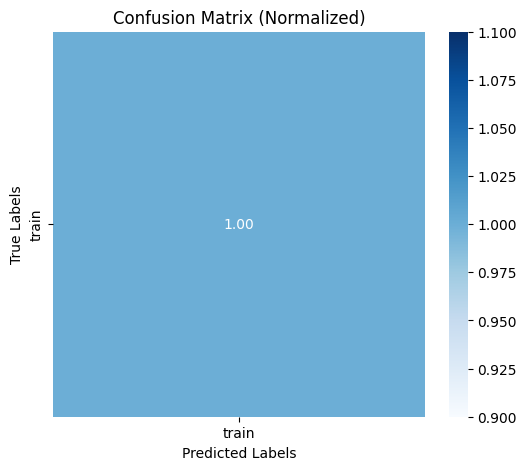


Classification Report:

              precision    recall  f1-score   support

       train       1.00      1.00      1.00      1500

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Step 1 — Collect all true and predicted labels
true_labels = []
pred_labels = []

for images, labels in train_ds:   # use test_ds if available
    predictions = model.predict(images)
    true_labels.extend(labels.numpy())
    pred_labels.extend(np.argmax(predictions, axis=1))

# Step 2 — Create confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Step 3 — Normalize the confusion matrix (optional)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Step 4 — Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (Normalized)')
plt.show()

# Step 5 — Print detailed classification report
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=class_names))


In [ ]:
import tensorflow as tf

# Set dataset directory — change this to your actual folder
DATA_DIR = "/content/skin-tone-classification-dataset"  # example path

# Load dataset from directory (split automatically)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(160, 160),
    batch_size=16
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(160, 160),
    batch_size=16
)


NotFoundError: Could not find directory /content/skin-tone-classification-dataset

In [ ]:
!ls /content



sample_data


In [ ]:
!pip install -q kaggle


In [ ]:
from google.colab import files
files.upload()  # Choose your kaggle.json file here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aashiiiiiii","key":"fa2ca40c08eaa05710196f03c78ba0a9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d usamarana/skin-tone-classification-dataset
!unzip -q skin-tone-classification-dataset.zip -d /content/skin_dataset


Dataset URL: https://www.kaggle.com/datasets/usamarana/skin-tone-classification-dataset
License(s): unknown
  0% 0.00/7.35M [00:00<?, ?B/s]
100% 7.35M/7.35M [00:00<00:00, 863MB/s]


In [ ]:
!ls /content/skin_dataset


train


In [ ]:
DATA_DIR = "/content/skin_dataset/train"


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(160, 160),
    batch_size=16
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(160, 160),
    batch_size=16
)


Found 1500 files belonging to 3 classes.
Using 1200 files for training.
Found 1500 files belonging to 3 classes.
Using 300 files for validation.


In [ ]:
print(train_ds.class_names)


['Black', 'Brown', 'White']


In [ ]:
from tensorflow.keras import layers, models

num_classes = 3  # based on the folders you just confirmed

# Build model
IMG_SIZE = (160, 160)
IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False  # freeze base

# Build final layers
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=10)


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 492ms/step - accuracy: 0.4583 - loss: 1.1644 - val_accuracy: 0.6033 - val_loss: 0.8037
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 28s 376ms/step - accuracy: 0.6744 - loss: 0.7547 - val_accuracy: 0.7033 - val_loss: 0.7021
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 43s 399ms/step - accuracy: 0.7189 - loss: 0.6385 - val_accuracy: 0.7533 - val_loss: 0.6167
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 40s 389ms/step - accuracy: 0.7502 - loss: 0.5551 - val_accuracy: 0.7367 - val_loss: 0.5957
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 29s 382ms/step - accuracy: 0.7945 - loss: 0.5039 - val_accuracy: 0.7500 - val_loss: 0.5829
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 46s 451ms/step - accuracy: 0.7786 - loss: 0.5201 - val_accuracy: 0.7567 - val_loss: 0.5920
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 41s 455ms/step - accuracy: 0.8000 - loss: 0.4749 - val_accuracy: 0.7567 - val_loss: 0.5528
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 450ms/step - accuracy: 0.8360 - loss: 0.4083 - val_accu